# Chicken GoGo Monthly Data Analyst Intern Analysis

This notebook organizes the Chicken GoGo analysis **by month**. It uses the uploaded PDF sales and payroll files to create a monthly business review.

## Source Files Used
- `CHICKEN GOGO-Sales Report 07_02_2026.pdf`
- `Chicken Gogo 5_15-6_1 Payroll.pdf`
- `Chicken Gogo 6_2-6_15 Payroll.pdf`
- `Chicken Gogo 6_16-7_1 Payroll.pdf`
- `Chicken Gogo 7_2-7_15 Payroll .pdf`

## Important Scope Note
The uploaded sales report only supports **June 2026 sales analysis**. The uploaded payroll files cover pay periods across **May, June, and July 2026**. Because daily payroll data is not available, monthly payroll is estimated by spreading each pay-period total evenly across the days in that pay period.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def money(x):
    return "" if pd.isna(x) else f"${float(x):,.2f}"

def pct(x):
    return "" if pd.isna(x) else f"{float(x):.1%}"

# Self-contained cleaned data extracted from the uploaded PDF files.
sales_daily = pd.read_json(StringIO('''[{"date":"2026-06-01T00:00:00.000","gross_sales":0.0,"discounts":0.0,"refunds":0.0,"net_sales":0.0,"overpayments":0.0,"taxes_expected":0.0,"taxes_collected":0.0,"tips_collected":0.0,"amount_collected":0.0,"active_day":false,"weekday":"Monday","tip_rate":null,"discount_rate":null,"refund_rate":null,"month":"2026-06"},{"date":"2026-06-02T00:00:00.000","gross_sales":0.0,"discounts":0.0,"refunds":0.0,"net_sales":0.0,"overpayments":0.0,"taxes_expected":0.0,"taxes_collected":0.0,"tips_collected":0.0,"amount_collected":0.0,"active_day":false,"weekday":"Tuesday","tip_rate":null,"discount_rate":null,"refund_rate":null,"month":"2026-06"},{"date":"2026-06-03T00:00:00.000","gross_sales":0.0,"discounts":0.0,"refunds":0.0,"net_sales":0.0,"overpayments":0.0,"taxes_expected":0.0,"taxes_collected":0.0,"tips_collected":0.0,"amount_collected":0.0,"active_day":false,"weekday":"Wednesday","tip_rate":null,"discount_rate":null,"refund_rate":null,"month":"2026-06"},{"date":"2026-06-04T00:00:00.000","gross_sales":0.0,"discounts":0.0,"refunds":0.0,"net_sales":0.0,"overpayments":0.0,"taxes_expected":0.0,"taxes_collected":0.0,"tips_collected":0.0,"amount_collected":0.0,"active_day":false,"weekday":"Thursday","tip_rate":null,"discount_rate":null,"refund_rate":null,"month":"2026-06"},{"date":"2026-06-05T00:00:00.000","gross_sales":0.0,"discounts":0.0,"refunds":0.0,"net_sales":0.0,"overpayments":0.0,"taxes_expected":0.0,"taxes_collected":0.0,"tips_collected":0.0,"amount_collected":0.0,"active_day":false,"weekday":"Friday","tip_rate":null,"discount_rate":null,"refund_rate":null,"month":"2026-06"},{"date":"2026-06-06T00:00:00.000","gross_sales":0.0,"discounts":0.0,"refunds":0.0,"net_sales":0.0,"overpayments":0.0,"taxes_expected":0.0,"taxes_collected":0.0,"tips_collected":0.0,"amount_collected":0.0,"active_day":false,"weekday":"Saturday","tip_rate":null,"discount_rate":null,"refund_rate":null,"month":"2026-06"},{"date":"2026-06-07T00:00:00.000","gross_sales":0.0,"discounts":0.0,"refunds":0.0,"net_sales":0.0,"overpayments":0.0,"taxes_expected":0.0,"taxes_collected":0.0,"tips_collected":0.0,"amount_collected":0.0,"active_day":false,"weekday":"Sunday","tip_rate":null,"discount_rate":null,"refund_rate":null,"month":"2026-06"},{"date":"2026-06-08T00:00:00.000","gross_sales":0.0,"discounts":0.0,"refunds":0.0,"net_sales":0.0,"overpayments":0.0,"taxes_expected":0.0,"taxes_collected":0.0,"tips_collected":0.0,"amount_collected":0.0,"active_day":false,"weekday":"Monday","tip_rate":null,"discount_rate":null,"refund_rate":null,"month":"2026-06"},{"date":"2026-06-09T00:00:00.000","gross_sales":2883.59,"discounts":-11.74,"refunds":0.0,"net_sales":2871.85,"overpayments":0.0,"taxes_expected":265.61,"taxes_collected":265.61,"tips_collected":155.56,"amount_collected":3293.02,"active_day":true,"weekday":"Tuesday","tip_rate":0.0541671745,"discount_rate":0.0040713139,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-10T00:00:00.000","gross_sales":2687.36,"discounts":-6.24,"refunds":0.0,"net_sales":2681.12,"overpayments":0.0,"taxes_expected":247.99,"taxes_collected":247.99,"tips_collected":135.34,"amount_collected":3064.45,"active_day":true,"weekday":"Wednesday","tip_rate":0.0504789043,"discount_rate":0.0023219814,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-11T00:00:00.000","gross_sales":2365.69,"discounts":-15.48,"refunds":-103.52,"net_sales":2246.69,"overpayments":0.0,"taxes_expected":207.81,"taxes_collected":207.81,"tips_collected":101.47,"amount_collected":2555.97,"active_day":true,"weekday":"Thursday","tip_rate":0.0451642194,"discount_rate":0.0065435454,"refund_rate":0.0437589033,"month":"2026-06"},{"date":"2026-06-12T00:00:00.000","gross_sales":2297.59,"discounts":-26.99,"refunds":0.0,"net_sales":2270.6,"overpayments":0.0,"taxes_expected":210.08,"taxes_collected":210.08,"tips_collected":96.29,"amount_collected":2576.97,"active_day":true,"weekday":"Friday","tip_rate":0.0424072932,"discount_rate":0.0117470915,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-13T00:00:00.000","gross_sales":2594.15,"discounts":-21.49,"refunds":0.0,"net_sales":2572.66,"overpayments":0.0,"taxes_expected":237.97,"taxes_collected":237.97,"tips_collected":161.71,"amount_collected":2972.34,"active_day":true,"weekday":"Saturday","tip_rate":0.0628571206,"discount_rate":0.0082840237,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-14T00:00:00.000","gross_sales":2380.86,"discounts":-1.85,"refunds":0.0,"net_sales":2379.01,"overpayments":0.0,"taxes_expected":220.06,"taxes_collected":220.06,"tips_collected":106.99,"amount_collected":2706.06,"active_day":true,"weekday":"Sunday","tip_rate":0.0449724886,"discount_rate":0.0007770301,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-15T00:00:00.000","gross_sales":2024.44,"discounts":-7.29,"refunds":0.0,"net_sales":2017.15,"overpayments":0.0,"taxes_expected":186.54,"taxes_collected":186.54,"tips_collected":113.42,"amount_collected":2317.11,"active_day":true,"weekday":"Monday","tip_rate":0.0562278462,"discount_rate":0.0036009958,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-16T00:00:00.000","gross_sales":2142.99,"discounts":-15.95,"refunds":0.0,"net_sales":2127.04,"overpayments":0.0,"taxes_expected":196.81,"taxes_collected":196.81,"tips_collected":108.55,"amount_collected":2432.4,"active_day":true,"weekday":"Tuesday","tip_rate":0.0510333609,"discount_rate":0.0074428719,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-17T00:00:00.000","gross_sales":2035.0,"discounts":-19.28,"refunds":0.0,"net_sales":2015.72,"overpayments":0.0,"taxes_expected":186.38,"taxes_collected":186.38,"tips_collected":104.92,"amount_collected":2307.02,"active_day":true,"weekday":"Wednesday","tip_rate":0.0520508801,"discount_rate":0.0094742015,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-18T00:00:00.000","gross_sales":2316.18,"discounts":-22.91,"refunds":-38.38,"net_sales":2254.89,"overpayments":0.0,"taxes_expected":208.62,"taxes_collected":208.62,"tips_collected":108.78,"amount_collected":2572.29,"active_day":true,"weekday":"Thursday","tip_rate":0.0482418211,"discount_rate":0.0098912865,"refund_rate":0.0165703874,"month":"2026-06"},{"date":"2026-06-19T00:00:00.000","gross_sales":2918.48,"discounts":-9.36,"refunds":0.0,"net_sales":2909.12,"overpayments":0.0,"taxes_expected":269.16,"taxes_collected":269.16,"tips_collected":141.29,"amount_collected":3319.57,"active_day":true,"weekday":"Friday","tip_rate":0.0485679518,"discount_rate":0.0032071489,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-20T00:00:00.000","gross_sales":1509.22,"discounts":-10.44,"refunds":0.0,"net_sales":1498.78,"overpayments":0.0,"taxes_expected":138.68,"taxes_collected":138.68,"tips_collected":57.5,"amount_collected":1694.96,"active_day":true,"weekday":"Saturday","tip_rate":0.0383645365,"discount_rate":0.0069174806,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-21T00:00:00.000","gross_sales":1739.77,"discounts":-6.2,"refunds":-86.59,"net_sales":1646.98,"overpayments":0.0,"taxes_expected":151.43,"taxes_collected":151.43,"tips_collected":120.74,"amount_collected":1919.15,"active_day":true,"weekday":"Sunday","tip_rate":0.073309937,"discount_rate":0.0035636895,"refund_rate":0.0497709467,"month":"2026-06"},{"date":"2026-06-22T00:00:00.000","gross_sales":2090.72,"discounts":-31.51,"refunds":-43.83,"net_sales":2015.38,"overpayments":0.0,"taxes_expected":186.41,"taxes_collected":186.41,"tips_collected":73.21,"amount_collected":2275.0,"active_day":true,"weekday":"Monday","tip_rate":0.0363256557,"discount_rate":0.015071363,"refund_rate":0.0209640698,"month":"2026-06"},{"date":"2026-06-23T00:00:00.000","gross_sales":1736.5,"discounts":-15.21,"refunds":0.0,"net_sales":1721.29,"overpayments":0.0,"taxes_expected":159.25,"taxes_collected":159.25,"tips_collected":90.09,"amount_collected":1970.63,"active_day":true,"weekday":"Tuesday","tip_rate":0.052338653,"discount_rate":0.008758998,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-24T00:00:00.000","gross_sales":1605.1,"discounts":-17.51,"refunds":0.0,"net_sales":1587.59,"overpayments":0.0,"taxes_expected":146.84,"taxes_collected":146.84,"tips_collected":88.25,"amount_collected":1822.68,"active_day":true,"weekday":"Wednesday","tip_rate":0.0555873998,"discount_rate":0.0109089776,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-25T00:00:00.000","gross_sales":2089.22,"discounts":-39.14,"refunds":0.0,"net_sales":2050.08,"overpayments":0.0,"taxes_expected":189.64,"taxes_collected":189.64,"tips_collected":92.1,"amount_collected":2331.82,"active_day":true,"weekday":"Thursday","tip_rate":0.0449250761,"discount_rate":0.0187342645,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-26T00:00:00.000","gross_sales":2583.27,"discounts":-22.03,"refunds":0.0,"net_sales":2561.24,"overpayments":8.7,"taxes_expected":236.88,"taxes_collected":237.68,"tips_collected":109.88,"amount_collected":2917.5,"active_day":true,"weekday":"Friday","tip_rate":0.0429010948,"discount_rate":0.008527951,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-27T00:00:00.000","gross_sales":1930.36,"discounts":-34.83,"refunds":0.0,"net_sales":1895.53,"overpayments":0.0,"taxes_expected":175.29,"taxes_collected":175.29,"tips_collected":105.9,"amount_collected":2176.72,"active_day":true,"weekday":"Saturday","tip_rate":0.0558682796,"discount_rate":0.0180432665,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-28T00:00:00.000","gross_sales":1977.08,"discounts":-51.31,"refunds":0.0,"net_sales":1925.77,"overpayments":0.0,"taxes_expected":178.07,"taxes_collected":178.07,"tips_collected":75.93,"amount_collected":2179.77,"active_day":true,"weekday":"Sunday","tip_rate":0.0394283845,"discount_rate":0.0259524147,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-29T00:00:00.000","gross_sales":1960.75,"discounts":-41.03,"refunds":0.0,"net_sales":1919.72,"overpayments":0.0,"taxes_expected":177.45,"taxes_collected":177.45,"tips_collected":83.78,"amount_collected":2180.95,"active_day":true,"weekday":"Monday","tip_rate":0.0436417811,"discount_rate":0.0209256662,"refund_rate":0.0,"month":"2026-06"},{"date":"2026-06-30T00:00:00.000","gross_sales":1514.5,"discounts":-29.91,"refunds":0.0,"net_sales":1484.59,"overpayments":0.0,"taxes_expected":137.35,"taxes_collected":137.35,"tips_collected":81.61,"amount_collected":1703.55,"active_day":true,"weekday":"Tuesday","tip_rate":0.0549714062,"discount_rate":0.0197490921,"refund_rate":0.0,"month":"2026-06"}]'''))
tenders = pd.read_json(StringIO('''[{"tender_type":"Credit and debit cards","amount":43644.34,"payout_money":null,"share_of_amount_collected":0.8189978857,"listed_total_minus_payout":null},{"tender_type":"Cash","amount":6351.24,"payout_money":null,"share_of_amount_collected":0.1191827424,"listed_total_minus_payout":null},{"tender_type":"DoorDash (include)","amount":2979.59,"payout_money":1524.26,"share_of_amount_collected":0.055912815,"listed_total_minus_payout":1455.33},{"tender_type":"Uber Eats (include)","amount":314.76,"payout_money":221.17,"share_of_amount_collected":0.0059065568,"listed_total_minus_payout":93.59}]'''))
payroll = pd.read_json(StringIO('''[{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Chao Lor","hours":6.42,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Justice Miles Cooper Sternin","hours":6.06,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Jaxon Darrell Jimenez","hours":6.06,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Betty Ross","hours":5.52,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Kaylee Marie Horak","hours":5.61,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Andrew Gin-Wah Yim","hours":6.17,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Alan Macias Nunez","hours":6.04,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Julian Salvador Palamidessi","hours":6.11,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Nevaeh Marie Jordan","hours":6.13,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Finnegan Andrew Butler","hours":5.51,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Emily Marie Gonzales","hours":2.99,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"McKenzie Lee Cagle","hours":5.51,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Amarion Ma kai Temple","hours":2.45,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Guowei He","hours":6.45,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Sophia Nikole Rybin","hours":2.94,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Audrey Rose Albano","hours":3.07,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"Cody tiago darosa ulicki","hours":5.08,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-05-15 to 2026-06-01","source_file":"Chicken Gogo 5_15-6_1 Payroll.pdf","employee":"David Cai","hours":3.93,"payroll_tips":0.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Source table labeled 'No tip'","period_start":"2026-05-15T00:00:00.000","period_end":"2026-06-01T00:00:00.000","payroll_tip_rate_per_hour":0.0,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-05 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Chao Lor","hours":36.18,"payroll_tips":72.36,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":72.36,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Justice Miles Cooper Sternin","hours":9.43,"payroll_tips":18.86,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":18.86,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Jaxon Darrell Jimenez","hours":30.81,"payroll_tips":61.62,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":61.62,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Betty Ross","hours":11.92,"payroll_tips":23.84,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":23.84,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Kaylee Marie Horak","hours":16.74,"payroll_tips":33.48,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":33.48,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Andrew Gin-Wah Yim","hours":31.93,"payroll_tips":63.86,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":63.86,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Alan Macias Nunez","hours":20.0,"payroll_tips":40.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":40.0,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Julian Salvador Palamidessi","hours":30.99,"payroll_tips":61.98,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":61.98,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Nevaeh Marie Jordan","hours":34.2,"payroll_tips":68.4,"bonus":30,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":98.4,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Finnegan Andrew Butler","hours":22.85,"payroll_tips":45.7,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":45.7,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Emily Marie Gonzales","hours":11.75,"payroll_tips":23.5,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":23.5,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"McKenzie Lee Cagle","hours":12.39,"payroll_tips":24.78,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":24.78,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Amarion Ma kai Temple","hours":7.51,"payroll_tips":15.02,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":15.02,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Guowei He","hours":33.17,"payroll_tips":66.34,"bonus":30,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":96.34,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Sophia Nikole Rybin","hours":21.74,"payroll_tips":43.48,"bonus":30,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":73.48,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Audrey Rose Albano","hours":16.83,"payroll_tips":33.66,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":33.66,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Cody tiago darosa ulicki","hours":18.63,"payroll_tips":37.26,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":37.26,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"David Cai","hours":10.78,"payroll_tips":21.56,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":21.56,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Juan Chen","hours":3.11,"payroll_tips":6.22,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":6.22,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Lingwei Qiu","hours":null,"payroll_tips":null,"bonus":150,"hourly_rate":null,"compensation_type":"fixed","fixed_amount":2500.0,"note":"Half month not hours","period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":null,"cash_compensation_before_hourly_wages":2650.0,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-02 to 2026-06-15","source_file":"Chicken Gogo 6_2-6_15 Payroll.pdf","employee":"Shiyi Teng","hours":null,"payroll_tips":null,"bonus":0,"hourly_rate":null,"compensation_type":"fixed","fixed_amount":2400.0,"note":"Half month not hours","period_start":"2026-06-02T00:00:00.000","period_end":"2026-06-15T00:00:00.000","payroll_tip_rate_per_hour":null,"cash_compensation_before_hourly_wages":2400.0,"period_month_label":"2026-06 to 2026-06","period_end_month":"2026-06"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Chao Lor","hours":44.93,"payroll_tips":89.86,"bonus":30,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":119.86,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Justice Miles Cooper Sternin","hours":33.31,"payroll_tips":66.62,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":66.62,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Jaxon Darrell Jimenez","hours":30.65,"payroll_tips":61.3,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":61.3,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Betty Ross","hours":11.92,"payroll_tips":23.84,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":23.84,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Kaylee Marie Horak","hours":11.94,"payroll_tips":null,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Fired (Already give)","period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":null,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Andrew Gin-Wah Yim","hours":52.85,"payroll_tips":105.7,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":105.7,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Michael Vincent Valverde","hours":15.87,"payroll_tips":null,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":"Fired (Already give)","period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":null,"cash_compensation_before_hourly_wages":0.0,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Julian Salvador Palamidessi","hours":47.59,"payroll_tips":95.18,"bonus":30,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":125.18,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Nevaeh Marie Jordan","hours":43.8,"payroll_tips":87.6,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":87.6,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Finnegan Andrew Butler","hours":44.63,"payroll_tips":89.26,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":89.26,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Emily Marie Gonzales","hours":31.51,"payroll_tips":63.02,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":63.02,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"McKenzie Lee Cagle","hours":21.71,"payroll_tips":43.42,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":43.42,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Amarion Ma kai Temple","hours":54.98,"payroll_tips":109.96,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":109.96,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Guowei He","hours":60.99,"payroll_tips":121.98,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":121.98,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Sophia Nikole Rybin","hours":32.75,"payroll_tips":65.5,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":65.5,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Audrey Rose Albano","hours":45.0,"payroll_tips":90.0,"bonus":30,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":120.0,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Cody tiago darosa ulicki","hours":14.42,"payroll_tips":28.84,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":28.84,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"David Cai","hours":34.89,"payroll_tips":69.78,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":69.78,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Juan Chen","hours":22.43,"payroll_tips":44.86,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":44.86,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Maribel Mejia","hours":29.42,"payroll_tips":58.84,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":58.84,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Joseph Itzko","hours":15.99,"payroll_tips":31.98,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":31.98,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Waleed Osman","hours":20.51,"payroll_tips":41.02,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":41.02,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Haley Mary Orozco","hours":11.82,"payroll_tips":23.64,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":23.64,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Bella Tern","hours":39.7,"payroll_tips":79.4,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":79.4,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Lingwei Qiu","hours":null,"payroll_tips":null,"bonus":150,"hourly_rate":null,"compensation_type":"fixed","fixed_amount":2500.0,"note":"Half month not hours; source table title appears inconsistent with file name","period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":null,"cash_compensation_before_hourly_wages":2650.0,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-06-16 to 2026-07-01","source_file":"Chicken Gogo 6_16-7_1 Payroll.pdf","employee":"Shiyi Teng","hours":null,"payroll_tips":null,"bonus":0,"hourly_rate":null,"compensation_type":"fixed","fixed_amount":2400.0,"note":"Half month not hours; source table title appears inconsistent with file name","period_start":"2026-06-16T00:00:00.000","period_end":"2026-07-01T00:00:00.000","payroll_tip_rate_per_hour":null,"cash_compensation_before_hourly_wages":2400.0,"period_month_label":"2026-06 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Audrey Rose Albano","hours":19.65,"payroll_tips":39.3,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":39.3,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Finnegan Andrew Butler","hours":22.32,"payroll_tips":44.64,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":44.64,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Mckenzie Lee Cagle","hours":21.83,"payroll_tips":43.66,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":43.66,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"David Cai","hours":21.72,"payroll_tips":43.44,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":43.44,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Guowei He","hours":37.59,"payroll_tips":75.18,"bonus":30,"hourly_rate":17.5,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":105.18,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Joseph Mark Itzko","hours":7.9,"payroll_tips":15.8,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":15.8,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Jaxon Darrell Jimenez","hours":23.62,"payroll_tips":47.24,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":47.24,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Nevaen Marie Jordan","hours":23.92,"payroll_tips":47.84,"bonus":0,"hourly_rate":17.5,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":47.84,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Chao Lor","hours":24.01,"payroll_tips":48.02,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":48.02,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Maribel Mejia","hours":22.85,"payroll_tips":45.7,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":45.7,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Waleed Osman","hours":19.5,"payroll_tips":39.0,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":39.0,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Julian Salvador Palamidessi","hours":19.95,"payroll_tips":39.9,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":39.9,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Betty Ross","hours":17.41,"payroll_tips":34.82,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":34.82,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Sophia Nikole Rybin","hours":28.53,"payroll_tips":57.06,"bonus":0,"hourly_rate":17.5,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":57.06,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Amarion Ma kai Temple","hours":11.78,"payroll_tips":23.56,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":23.56,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Bella Tango Tern","hours":19.43,"payroll_tips":38.86,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":38.86,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Cody tiago darosa ulicki","hours":20.07,"payroll_tips":40.14,"bonus":0,"hourly_rate":null,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":40.14,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Andrew Gin-Wah Yim","hours":15.4,"payroll_tips":30.8,"bonus":0,"hourly_rate":17.5,"compensation_type":"hourly","fixed_amount":null,"note":null,"period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":2.0,"cash_compensation_before_hourly_wages":30.8,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Justin Hu","hours":null,"payroll_tips":null,"bonus":0,"hourly_rate":null,"compensation_type":"fixed","fixed_amount":350.0,"note":"Half month not hours","period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":null,"cash_compensation_before_hourly_wages":350.0,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Jayden Hu","hours":null,"payroll_tips":null,"bonus":0,"hourly_rate":null,"compensation_type":"fixed","fixed_amount":350.0,"note":"Half month not hours","period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":null,"cash_compensation_before_hourly_wages":350.0,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Lingwei Qiu","hours":null,"payroll_tips":null,"bonus":150,"hourly_rate":null,"compensation_type":"fixed","fixed_amount":2500.0,"note":"Half month not hours","period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":null,"cash_compensation_before_hourly_wages":2650.0,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"},{"period":"2026-07-02 to 2026-07-15","source_file":"Chicken Gogo 7_2-7_15 Payroll .pdf","employee":"Shiyi Teng","hours":null,"payroll_tips":null,"bonus":0,"hourly_rate":null,"compensation_type":"fixed","fixed_amount":2400.0,"note":"Half month not hours","period_start":"2026-07-02T00:00:00.000","period_end":"2026-07-15T00:00:00.000","payroll_tip_rate_per_hour":null,"cash_compensation_before_hourly_wages":2400.0,"period_month_label":"2026-07 to 2026-07","period_end_month":"2026-07"}]'''))
data_quality = pd.read_json(StringIO('''[{"check":"Amount collected reconciliation","status":"Pass","finding":"Amount collected equals net sales + taxes collected + tips + overpayments within $0.00."},{"check":"Tax reconciliation","status":"Review","finding":"Taxes collected exceeded taxes expected by $0.80."},{"check":"Sales report zero activity days","status":"Review","finding":"June 1-8 show $0 sales, while June 9-30 show activity. Confirm whether the store opened on June 9 or whether earlier data is missing."},{"check":"Payroll file naming","status":"Review","finding":"The uploaded file named 6_16-7_1 has an internal table title that still reads 6\/2-6\/15, so the pay period should be verified."},{"check":"Payroll total hours field","status":"Review","finding":"The 7\/2-7\/15 payroll total line mixes hourly hours with fixed half-month amounts, so fixed amounts were separated from actual labor hours."},{"check":"Payroll tip method","status":"Review","finding":"Most payroll tips equal approximately $2 per labor hour. This appears to be a distribution rule, not itemized POS tip distribution."}]'''))

sales_daily["date"] = pd.to_datetime(sales_daily["date"])
payroll["period_start"] = pd.to_datetime(payroll["period_start"])
payroll["period_end"] = pd.to_datetime(payroll["period_end"])

sales_summary = {
    "sales_period": "2026-06-01 to 2026-06-30",
    "requested_on": "2026-07-02 14:50",
    "net_sales": 46652.80,
    "orders": 2524,
    "amount_collected": 53289.93,
    "gross_sales": 47382.82,
    "discounts": -457.70,
    "refunds": -272.32,
    "overpayments": 8.70,
    "taxes_expected": 4314.32,
    "taxes_collected": 4315.12,
    "tips": 2313.31
}

display(sales_daily.head())
display(payroll.head())

<>:19: SyntaxWarning: invalid escape sequence '\/'
<>:19: SyntaxWarning: invalid escape sequence '\/'
/tmp/ipykernel_1529/2627790304.py:19: SyntaxWarning: invalid escape sequence '\/'
  data_quality = pd.read_json(StringIO('''[{"check":"Amount collected reconciliation","status":"Pass","finding":"Amount collected equals net sales + taxes collected + tips + overpayments within $0.00."},{"check":"Tax reconciliation","status":"Review","finding":"Taxes collected exceeded taxes expected by $0.80."},{"check":"Sales report zero activity days","status":"Review","finding":"June 1-8 show $0 sales, while June 9-30 show activity. Confirm whether the store opened on June 9 or whether earlier data is missing."},{"check":"Payroll file naming","status":"Review","finding":"The uploaded file named 6_16-7_1 has an internal table title that still reads 6\/2-6\/15, so the pay period should be verified."},{"check":"Payroll total hours field","status":"Review","finding":"The 7\/2-7\/15 payroll total line mixe

,date,gross_sales,discounts,refunds,net_sales,overpayments,taxes_expected,taxes_collected,tips_collected,amount_collected,active_day,weekday,tip_rate,discount_rate,refund_rate,month
0,2026-06-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,Monday,NaN,NaN,NaN,2026-06
1,2026-06-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,Tuesday,NaN,NaN,NaN,2026-06
2,2026-06-03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,Wednesday,NaN,NaN,NaN,2026-06
3,2026-06-04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,Thursday,NaN,NaN,NaN,2026-06
4,2026-06-05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,False,Friday,NaN,NaN,NaN,2026-06


,period,source_file,employee,hours,payroll_tips,bonus,hourly_rate,compensation_type,fixed_amount,note,period_start,period_end,payroll_tip_rate_per_hour,cash_compensation_before_hourly_wages,period_month_label,period_end_month
0,2026-05-15 to 2026-06-01,Chicken Gogo 5_15-6_1 Payroll.pdf,Chao Lor,6.42,0.00,0,NaN,hourly,NaN,Source table labeled 'No tip',2026-05-15,2026-06-01,0.00,0.00,2026-05 to 2026-06,2026-06
1,2026-05-15 to 2026-06-01,Chicken Gogo 5_15-6_1 Payroll.pdf,Justice Miles Cooper Sternin,6.06,0.00,0,NaN,hourly,NaN,Source table labeled 'No tip',2026-05-15,2026-06-01,0.00,0.00,2026-05 to 2026-06,2026-06
2,2026-05-15 to 2026-06-01,Chicken Gogo 5_15-6_1 Payroll.pdf,Jaxon Darrell Jimenez,6.06,0.00,0,NaN,hourly,NaN,Source table labeled 'No tip',2026-05-15,2026-06-01,0.00,0.00,2026-05 to 2026-06,2026-06
3,2026-05-15 to 2026-06-01,Chicken Gogo 5_15-6_1 Payroll.pdf,Betty Ross,5.52,0.00,0,NaN,hourly,NaN,Source table labeled 'No tip',2026-05-15,2026-06-01,0.00,0.00,2026-05 to 2026-06,2026-06
4,2026-05-15 to 2026-06-01,Chicken Gogo 5_15-6_1 Payroll.pdf,Kaylee Marie Horak,5.61,0.00,0,NaN,hourly,NaN,Source table labeled 'No tip',2026-05-15,2026-06-01,0.00,0.00,2026-05 to 2026-06,2026-06


## 1. Data Quality Review

In [2]:
data_quality

,check,status,finding
0,Amount collected reconciliation,Pass,Amount collected equals net sales + taxes coll...
1,Tax reconciliation,Review,Taxes collected exceeded taxes expected by $0.80.
2,Sales report zero activity days,Review,"June 1-8 show $0 sales, while June 9-30 show a..."
3,Payroll file naming,Review,The uploaded file named 6_16-7_1 has an intern...
4,Payroll total hours field,Review,The 7/2-7/15 payroll total line mixes hourly h...
5,Payroll tip method,Review,Most payroll tips equal approximately $2 per l...


## 2. Monthly Sales Summary
The provided sales data only supports June 2026.

In [3]:
sales_daily["month"] = sales_daily["date"].dt.to_period("M").astype(str)
sales_daily["active_day"] = sales_daily["net_sales"] > 0

monthly_sales = sales_daily.groupby("month", as_index=False).agg(
    gross_sales=("gross_sales", "sum"),
    discounts=("discounts", "sum"),
    refunds=("refunds", "sum"),
    net_sales=("net_sales", "sum"),
    taxes_collected=("taxes_collected", "sum"),
    tips_collected=("tips_collected", "sum"),
    amount_collected=("amount_collected", "sum"),
    active_sales_days=("active_day", "sum")
)
monthly_sales["orders"] = [sales_summary["orders"]]
monthly_sales["avg_order_value"] = monthly_sales["net_sales"] / monthly_sales["orders"]
monthly_sales["tip_rate"] = monthly_sales["tips_collected"] / monthly_sales["net_sales"]
monthly_sales["refund_rate"] = monthly_sales["refunds"].abs() / monthly_sales["gross_sales"]
monthly_sales["discount_rate"] = monthly_sales["discounts"].abs() / monthly_sales["gross_sales"]

monthly_sales

,month,gross_sales,discounts,refunds,net_sales,taxes_collected,tips_collected,amount_collected,active_sales_days,orders,avg_order_value,tip_rate,refund_rate,discount_rate
0,2026-06,"47,382.82",-457.70,-272.32,"46,652.80","4,315.12","2,313.31","53,289.93",22,2524,18.48,0.05,0.01,0.01


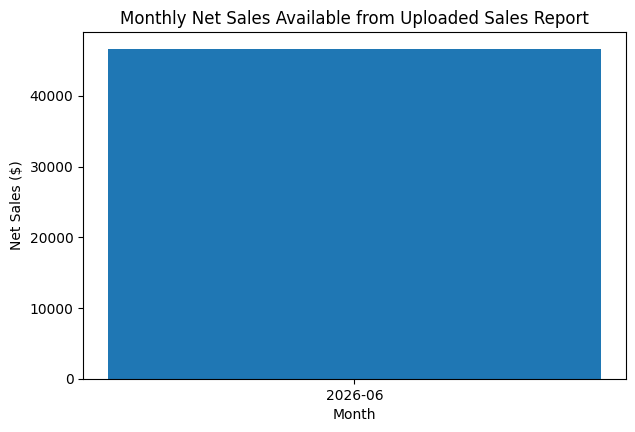

In [4]:
plt.figure(figsize=(7, 4.5))
plt.bar(monthly_sales["month"], monthly_sales["net_sales"])
plt.title("Monthly Net Sales Available from Uploaded Sales Report")
plt.xlabel("Month")
plt.ylabel("Net Sales ($)")
plt.show()

## 3. June Daily Sales Detail

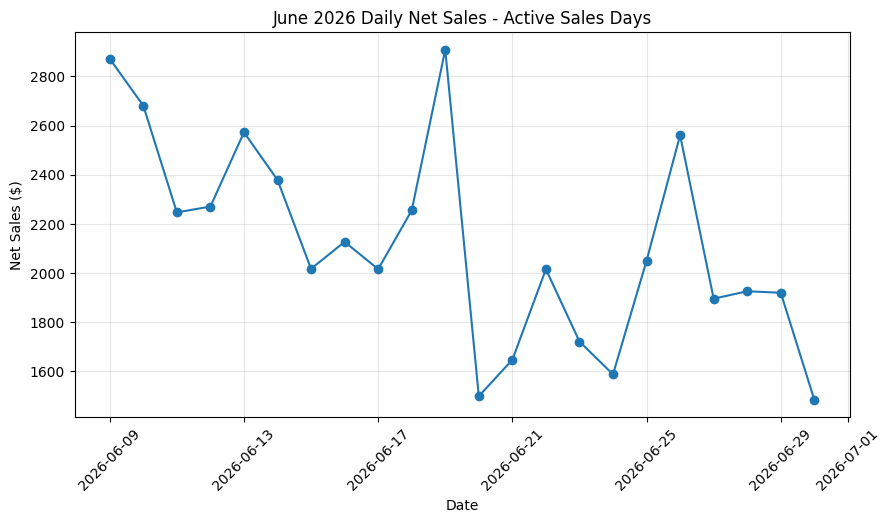

,date,gross_sales,discounts,refunds,net_sales,overpayments,taxes_expected,taxes_collected,tips_collected,amount_collected,active_day,weekday,tip_rate,discount_rate,refund_rate,month
18,2026-06-19,"2,918.48",-9.36,0.00,"2,909.12",0.00,269.16,269.16,141.29,"3,319.57",True,Friday,0.05,0.00,0.00,2026-06
8,2026-06-09,"2,883.59",-11.74,0.00,"2,871.85",0.00,265.61,265.61,155.56,"3,293.02",True,Tuesday,0.05,0.00,0.00,2026-06
9,2026-06-10,"2,687.36",-6.24,0.00,"2,681.12",0.00,247.99,247.99,135.34,"3,064.45",True,Wednesday,0.05,0.00,0.00,2026-06
12,2026-06-13,"2,594.15",-21.49,0.00,"2,572.66",0.00,237.97,237.97,161.71,"2,972.34",True,Saturday,0.06,0.01,0.00,2026-06
25,2026-06-26,"2,583.27",-22.03,0.00,"2,561.24",8.70,236.88,237.68,109.88,"2,917.50",True,Friday,0.04,0.01,0.00,2026-06
13,2026-06-14,"2,380.86",-1.85,0.00,"2,379.01",0.00,220.06,220.06,106.99,"2,706.06",True,Sunday,0.04,0.00,0.00,2026-06
11,2026-06-12,"2,297.59",-26.99,0.00,"2,270.60",0.00,210.08,210.08,96.29,"2,576.97",True,Friday,0.04,0.01,0.00,2026-06
17,2026-06-18,"2,316.18",-22.91,-38.38,"2,254.89",0.00,208.62,208.62,108.78,"2,572.29",True,Thursday,0.05,0.01,0.02,2026-06
10,2026-06-11,"2,365.69",-15.48,-103.52,"2,246.69",0.00,207.81,207.81,101.47,"2,555.97",True,Thursday,0.05,0.01,0.04,2026-06
15,2026-06-16,"2,142.99",-15.95,0.00,"2,127.04",0.00,196.81,196.81,108.55,"2,432.40",True,Tuesday,0.05,0.01,0.00,2026-06


In [5]:
active_sales = sales_daily[sales_daily["net_sales"] > 0].copy()

plt.figure(figsize=(10,5))
plt.plot(active_sales["date"], active_sales["net_sales"], marker="o")
plt.title("June 2026 Daily Net Sales - Active Sales Days")
plt.xlabel("Date")
plt.ylabel("Net Sales ($)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

active_sales.sort_values("net_sales", ascending=False).head(10)

## 4. Payroll Period Summary
This keeps the original pay-period view before converting payroll into monthly estimates.

In [6]:
payroll["cash_compensation_before_hourly_wages"] = (
    payroll["payroll_tips"].fillna(0) 
    + payroll["bonus"].fillna(0) 
    + payroll["fixed_amount"].fillna(0)
)

payroll_period_summary = payroll.groupby("period", as_index=False).agg(
    period_start=("period_start", "min"),
    period_end=("period_end", "max"),
    hourly_employee_records=("hours", lambda x: x.notna().sum()),
    total_hourly_hours=("hours", "sum"),
    payroll_tips=("payroll_tips", "sum"),
    bonus=("bonus", "sum"),
    fixed_amount=("fixed_amount", "sum"),
    cash_comp_before_hourly_wages=("cash_compensation_before_hourly_wages", "sum")
)

payroll_period_summary

,period,period_start,period_end,hourly_employee_records,total_hourly_hours,payroll_tips,bonus,fixed_amount,cash_comp_before_hourly_wages
0,2026-05-15 to 2026-06-01,2026-05-15,2026-06-01,18,92.05,0.00,0,0.00,0.00
1,2026-06-02 to 2026-06-15,2026-06-02,2026-06-15,19,380.96,761.92,240,"4,900.00","5,901.92"
2,2026-06-16 to 2026-07-01,2026-06-16,2026-07-01,24,773.61,"1,491.60",240,"4,900.00","6,631.60"
3,2026-07-02 to 2026-07-15,2026-07-02,2026-07-15,18,377.48,754.96,180,"5,600.00","6,534.96"


## 5. Monthly Payroll Allocation Method
Because pay periods cross month boundaries, each employee/pay-period row is spread evenly across each day in that pay period. This creates an estimated calendar-month payroll summary.

In [7]:
metrics = ["hours", "payroll_tips", "bonus", "fixed_amount", "cash_compensation_before_hourly_wages"]
alloc_rows = []

for _, row in payroll.iterrows():
    days = pd.date_range(start=row["period_start"], end=row["period_end"], freq="D")
    n_days = len(days)
    for d in days:
        out = {
            "date": d,
            "month": d.to_period("M").strftime("%Y-%m"),
            "employee": row["employee"],
            "period": row["period"],
            "compensation_type": row["compensation_type"]
        }
        for m in metrics:
            val = row[m] if pd.notna(row[m]) else 0
            out[m] = val / n_days
        alloc_rows.append(out)

payroll_allocated_daily = pd.DataFrame(alloc_rows)

monthly_payroll_allocated = payroll_allocated_daily.groupby("month", as_index=False).agg(
    allocated_hours=("hours", "sum"),
    allocated_payroll_tips=("payroll_tips", "sum"),
    allocated_bonus=("bonus", "sum"),
    allocated_fixed_amount=("fixed_amount", "sum"),
    allocated_cash_comp_before_hourly_wages=("cash_compensation_before_hourly_wages", "sum")
)

monthly_payroll_allocated

,month,allocated_hours,allocated_payroll_tips,allocated_bonus,allocated_fixed_amount,allocated_cash_comp_before_hourly_wages
0,2026-05,86.94,0.00,0.00,0.00,0.00
1,2026-06,"1,111.33","2,160.30",465.00,"9,493.75","12,119.05"
2,2026-07,425.83,848.19,195.00,"5,906.25","6,949.43"


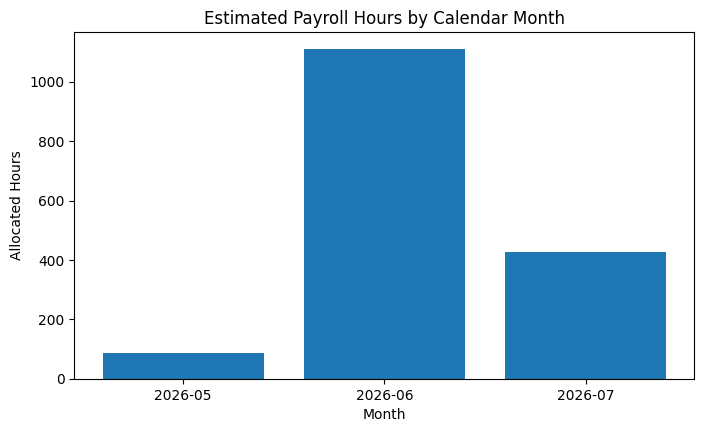

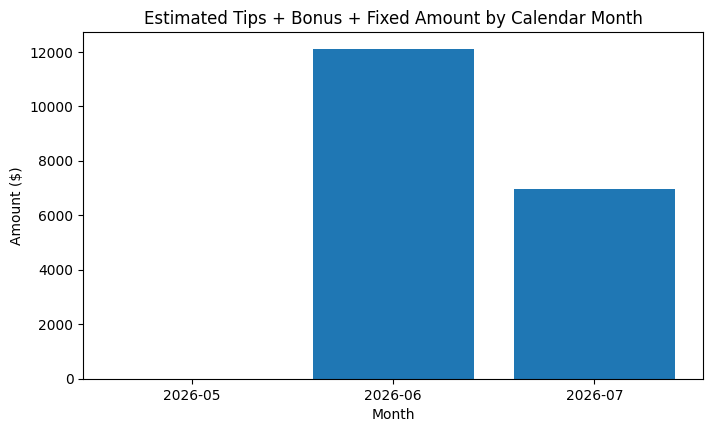

In [8]:
plt.figure(figsize=(8, 4.5))
plt.bar(monthly_payroll_allocated["month"], monthly_payroll_allocated["allocated_hours"])
plt.title("Estimated Payroll Hours by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Allocated Hours")
plt.show()

plt.figure(figsize=(8, 4.5))
plt.bar(monthly_payroll_allocated["month"], monthly_payroll_allocated["allocated_cash_comp_before_hourly_wages"])
plt.title("Estimated Tips + Bonus + Fixed Amount by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Amount ($)")
plt.show()

## 6. Monthly Sales and Labor Combined View

In [9]:
monthly_combined = pd.merge(
    monthly_payroll_allocated, 
    monthly_sales[["month", "net_sales", "orders", "tips_collected", "amount_collected"]], 
    on="month", 
    how="left"
)

monthly_combined["sales_per_allocated_labor_hour"] = monthly_combined["net_sales"] / monthly_combined["allocated_hours"]
monthly_combined["sales_data_available"] = np.where(monthly_combined["net_sales"].notna(), "Yes", "No")

monthly_combined

,month,allocated_hours,allocated_payroll_tips,allocated_bonus,allocated_fixed_amount,allocated_cash_comp_before_hourly_wages,net_sales,orders,tips_collected,amount_collected,sales_per_allocated_labor_hour,sales_data_available
0,2026-05,86.94,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,No
1,2026-06,"1,111.33","2,160.30",465.00,"9,493.75","12,119.05","46,652.80","2,524.00","2,313.31","53,289.93",41.98,Yes
2,2026-07,425.83,848.19,195.00,"5,906.25","6,949.43",NaN,NaN,NaN,NaN,NaN,No


## 7. June Labor Efficiency Benchmark

In [10]:
june_row = monthly_combined[monthly_combined["month"] == "2026-06"].iloc[0]

june_kpis = pd.DataFrame({
    "KPI": [
        "June net sales",
        "June orders",
        "June allocated payroll hours",
        "June estimated sales per allocated labor hour",
        "June collected tips",
        "June allocated payroll tips"
    ],
    "Value": [
        money(june_row["net_sales"]),
        f"{int(june_row['orders']):,}",
        f"{june_row['allocated_hours']:,.2f}",
        money(june_row["sales_per_allocated_labor_hour"]),
        money(june_row["tips_collected"]),
        money(june_row["allocated_payroll_tips"])
    ]
})

june_kpis

,KPI,Value
0,June net sales,"$46,652.80"
1,June orders,"2,524"
2,June allocated payroll hours,"1,111.33"
3,June estimated sales per allocated labor hour,$41.98
4,June collected tips,"$2,313.31"
5,June allocated payroll tips,"$2,160.30"


## 8. Tender Analysis for June

,tender_type,amount,payout_money,share_of_amount_collected,listed_total_minus_payout
0,Credit and debit cards,"43,644.34",NaN,0.82,NaN
1,Cash,"6,351.24",NaN,0.12,NaN
2,DoorDash (include),"2,979.59","1,524.26",0.06,"1,455.33"
3,Uber Eats (include),314.76,221.17,0.01,93.59


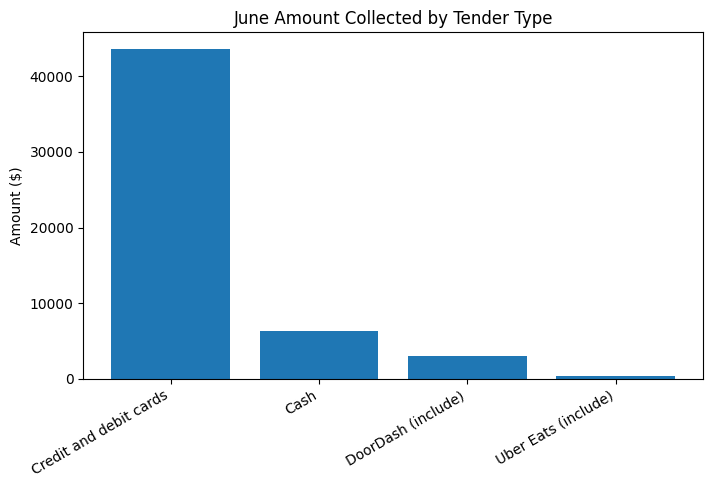

In [11]:
tenders["share_of_amount_collected"] = tenders["amount"] / sales_summary["amount_collected"]
tenders["listed_total_minus_payout"] = tenders["amount"] - tenders["payout_money"]

display(tenders)

plt.figure(figsize=(8, 4.5))
plt.bar(tenders["tender_type"], tenders["amount"])
plt.title("June Amount Collected by Tender Type")
plt.ylabel("Amount ($)")
plt.xticks(rotation=30, ha="right")
plt.show()

## 9. Recommendations

In [12]:
recommendations = pd.DataFrame([
    ["High", "Monthly reporting", "Create one monthly folder for POS sales, payroll, delivery payouts, inventory, and scheduling files.", "Owner / manager"],
    ["High", "Payroll allocation", "Keep hourly labor, fixed salaries, tips, and bonuses in separate columns so monthly reports do not mix hours with fixed payments.", "Payroll manager"],
    ["High", "Sales data coverage", "Export full POS sales reports every month. May and July sales were not provided, so the current month-by-month sales analysis only supports June.", "Manager"],
    ["High", "Tip reconciliation", "Reconcile collected tips against payroll tip payout by month and by pay period before each pay date.", "Manager / payroll"],
    ["Medium", "Labor efficiency", "Track sales per labor hour monthly. For June, estimated sales per allocated labor hour is shown as a benchmark.", "Operations lead"],
    ["Medium", "Delivery platforms", "Match DoorDash and Uber Eats listed sales to payout deposits each month.", "Manager"],
    ["Medium", "Dashboard process", "Use this workflow to refresh a monthly dashboard after each payroll cycle.", "Data analyst intern"],
], columns=["Priority","Area","Recommended Action","Owner"])

recommendations

,Priority,Area,Recommended Action,Owner
0,High,Monthly reporting,"Create one monthly folder for POS sales, payro...",Owner / manager
1,High,Payroll allocation,"Keep hourly labor, fixed salaries, tips, and b...",Payroll manager
2,High,Sales data coverage,Export full POS sales reports every month. May...,Manager
3,High,Tip reconciliation,Reconcile collected tips against payroll tip p...,Manager / payroll
4,Medium,Labor efficiency,"Track sales per labor hour monthly. For June, ...",Operations lead
5,Medium,Delivery platforms,Match DoorDash and Uber Eats listed sales to p...,Manager
6,Medium,Dashboard process,Use this workflow to refresh a monthly dashboa...,Data analyst intern


## 10. Limitations and Next Steps

### Limitations
- Only June sales data was available, so May and July sales performance cannot be evaluated from the provided files.
- Payroll periods cross month boundaries, so monthly payroll is estimated by daily allocation.
- The payroll PDFs do not include daily clock-in/out detail, so the monthly labor split may differ from actual daily labor.
- The report would be stronger with item-level POS sales, hourly sales, customer count, inventory usage, and delivery platform payout statements.

### Next Steps
1. Export one POS sales report for every month.
2. Export payroll in a clean table with separate fields for hours, fixed pay, tips, and bonuses.
3. Match DoorDash and Uber Eats sales to monthly payout deposits.
4. Track hourly sales and actual clock-in/out records.
5. Build a repeatable monthly dashboard for sales, labor, tips, and exceptions.